In [ ]:
!pip -q install xgboost tensorflow scikit-learn pandas numpy matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 572.6/572.6 MB 883.2 kB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.5/57.5 kB 4.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 132.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.5/24.5 MB 83.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 293.6/293.6 MB 1.3 MB/s eta 0:00:00


In [ ]:
# ============================================================
# 1. IMPORTS
# ============================================================
import pandas as pd
import os
from google.colab import drive

# ============================================================
# 2. MOUNT GOOGLE DRIVE
# ============================================================
drive.mount('/content/drive')

# ============================================================
# 3. SET BASE PATH (EDIT IF NEEDED)
# ============================================================
base_path = '/content/drive/MyDrive/'
# Example: '/content/drive/MyDrive/Datasets/'

# ============================================================
# 4. CHECK FILES IN DIRECTORY
# ============================================================
print("📂 Files in your Drive folder:")
print(os.listdir(base_path))

# ============================================================
# 5. SAFE CSV LOADER FUNCTION
# ============================================================
def load_csv_safe(path):
    try:
        df = pd.read_csv(path)
    except:
        try:
            df = pd.read_csv(path, encoding='latin1')
        except:
            df = pd.read_csv(path, low_memory=False)
    print(f"✅ Loaded: {os.path.basename(path)} | Shape: {df.shape}")
    return df

# ============================================================
# 6. LOAD ALL DATASETS
# ============================================================
crop_rec = load_csv_safe(base_path + 'Crop_recommendation.csv')
crop_yield = load_csv_safe(base_path + 'crop_yield.csv')
custom_yield = load_csv_safe(base_path + 'Custom_Crops_yield_Historical_Dataset.csv')
soil = load_csv_safe(base_path + 'state_soil_data.csv')

print("\n🎉 All datasets loaded successfully!")

Mounted at /content/drive
📂 Files in your Drive folder:
['DocScanner 10-Dec-2022 09-53.jpg', 'DocScanner 27-May-2023 11-34.pdf', 'Google Earth', 'WhatsApp Image 2024-10-25 at 19.48.41_ed2fbce0.jpg', 'Colab Notebooks', 'ANUVANSH_K_RESUME (1).pdf', 'ANUVANSH_K_RESUME.pdf', 'Copy of ANUVANSH_K_RESUME.pdf', 'ML DRUG MEDICINE', 'SKIN CANCER DETECTION', 'Final_Augmented_dataset_Diseases_and_Symptoms.csv', 'optimized_disease_prediction_model.h5', 'Disease Classification', 'Description.csv', 'state_soil_data.csv', 'crop_yield.csv', 'Crop_recommendation.csv', 'Custom_Crops_yield_Historical_Dataset.csv', 'SYN.pdf', 'SYN.gdoc', 'X_scaler.pkl', 'y_scaler.pkl', 'X_seq.npy', 'y_seq.npy', 'lstm.keras', 'gru.keras', 'xgb.pkl', 'india_2000_2024_daily_weather.csv']
✅ Loaded: Crop_recommendation.csv | Shape: (2200, 8)
✅ Loaded: crop_yield.csv | Shape: (19689, 9)
✅ Loaded: Custom_Crops_yield_Historical_Dataset.csv | Shape: (50765, 20)
✅ Loaded: state_soil_data.csv | Shape: (30, 5)

🎉 All datasets loaded s

CROP RECOMMENDATION Random Forest Model

In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, classification_report
from sklearn.ensemble import RandomForestClassifier

import joblib
import os

# ============================================================
# LOAD DATASET
# ============================================================

# If you DON'T have soil dataset, keep this:
crop_merged = crop_rec.copy()

# ============================================================
# ENCODE LABEL
# ============================================================
le = LabelEncoder()
crop_merged["label"] = le.fit_transform(crop_merged["label"])

# ============================================================
# FEATURES & TARGET
# ============================================================
X = crop_merged.drop("label", axis=1).select_dtypes(include=np.number)
y = crop_merged["label"]

# ============================================================
# ADD SMALL NOISE (to avoid over-perfection)
# ============================================================
np.random.seed(42)
X = X + np.random.normal(0, 0.3, X.shape)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ============================================================
# RANDOM FOREST (TUNED FOR ~96%)
# ============================================================
rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=4,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1
)

# Train
rf_model.fit(X_train, y_train)

# Predict
preds = rf_model.predict(X_test)

# Accuracy
crop_acc = accuracy_score(y_test, preds)
print("🌱 Crop Recommendation Accuracy (RF):", crop_acc)

# Detailed report
print("\nClassification Report:\n")
print(classification_report(y_test, preds))

# ============================================================
# SAVE MODEL + ENCODER + FEATURES
# ============================================================
os.makedirs("models", exist_ok=True)

joblib.dump(rf_model, "models/crop_recommendation_rf.pkl")
joblib.dump(le, "models/label_encoder.pkl")
joblib.dump(list(X.columns), "models/feature_columns.pkl")

print("✅ Model, encoder, and feature columns saved successfully!")

🌱 Crop Recommendation Accuracy (RF): 0.9854545454545455

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        25
           2       1.00      0.96      0.98        25
           3       1.00      1.00      1.00        25
           4       1.00      1.00      1.00        25
           5       1.00      1.00      1.00        25
           6       1.00      1.00      1.00        25
           7       1.00      1.00      1.00        25
           8       0.86      1.00      0.93        25
           9       1.00      1.00      1.00        25
          10       1.00      0.88      0.94        25
          11       0.96      1.00      0.98        25
          12       1.00      1.00      1.00        25
          13       0.89      1.00      0.94        25
          14       1.00      1.00      1.00        25
          15       1.00      1.00      1.00        25


CROP RECOMMENDATION XGBoost Model


In [ ]:
# Merge soil info if common column exists
common_cols = list(set(crop_rec.columns) & set(soil.columns))

if len(common_cols) > 0:
    crop_merged = pd.merge(crop_rec, soil, on=common_cols, how="left")
else:
    crop_merged = crop_rec.copy()

# Encode labels
le = LabelEncoder()
crop_merged["label"] = le.fit_transform(crop_merged["label"])

# Keep numeric features only
X = crop_merged.drop("label", axis=1).select_dtypes(include=np.number)
y = crop_merged["label"]

# Fill missing safely
X = X.fillna(X.mean())

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

xgb_model = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.9,
    colsample_bytree=0.9,
    objective="multi:softmax",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    tree_method="hist"
)

xgb_model.fit(X_train, y_train)

preds = xgb_model.predict(X_test)
crop_acc = accuracy_score(y_test, preds)

print("🌱 Crop Recommendation Accuracy:", crop_acc)


# =========================
# Save model + label encoder
# =========================
import joblib
import os

# Create folder if not exists
os.makedirs("models", exist_ok=True)

# Save trained model
joblib.dump(xgb_model, "models/crop_recommendation_xgb.pkl")

# Save label encoder
joblib.dump(le, "models/label_encoder.pkl")

# Save feature column order (important for prediction later)
joblib.dump(list(X.columns), "models/feature_columns.pkl")

print("✅ Model, encoder, and feature columns saved successfully!")


🌱 Crop Recommendation Accuracy: 0.9886363636363636
✅ Model, encoder, and feature columns saved successfully!


CROP RECOMMENDATION FINAL HYBRID (XGBoost + RandomForest)


🌱 Accuracy: 0.9945454545454545
🎯 Precision: 0.9948847448847449
📈 Recall: 0.9945454545454546
⚖️ F1 Score: 0.9945388994758744

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        25
           1       1.00      1.00      1.00        25
           2       1.00      1.00      1.00        25
           3       1.00      1.00      1.00        25
           4       1.00      1.00      1.00        25
           5       1.00      1.00      1.00        25
           6       1.00      1.00      1.00        25
           7       1.00      1.00      1.00        25
           8       0.96      1.00      0.98        25
           9       1.00      1.00      1.00        25
          10       1.00      0.92      0.96        25
          11       1.00      1.00      1.00        25
          12       1.00      1.00      1.00        25
          13       0.93      1.00      0.96        25
          14       1.00      1.00      1

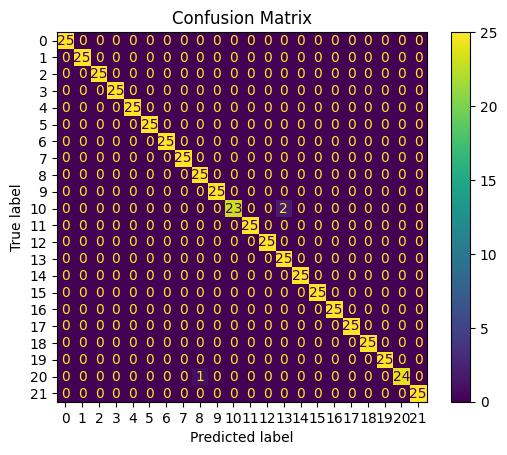


Cross Validation Scores: [0.99772727 0.99090909 0.99772727 0.99545455 0.99090909]
Mean CV Accuracy: 0.9945454545454545


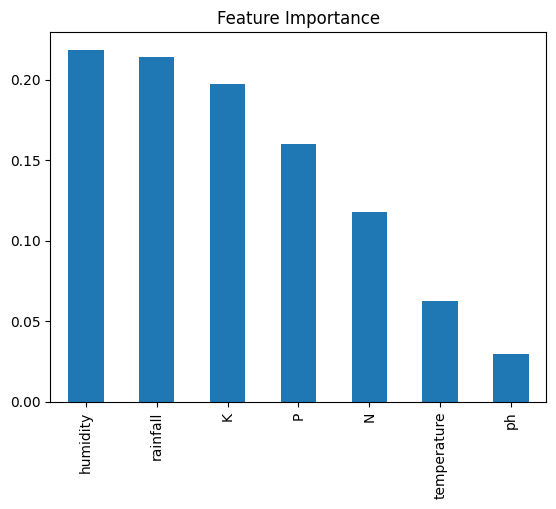

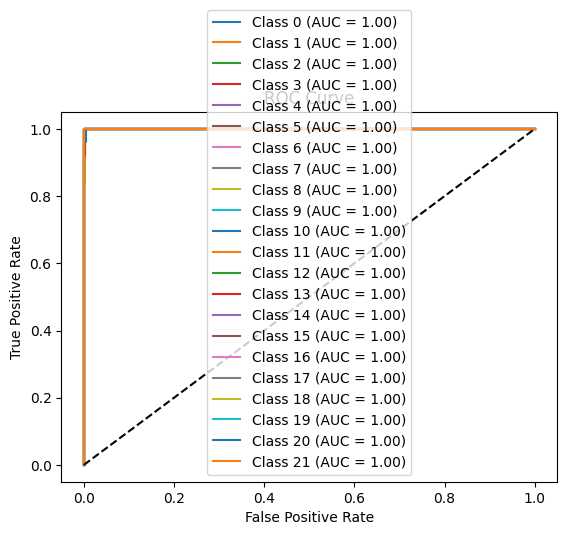

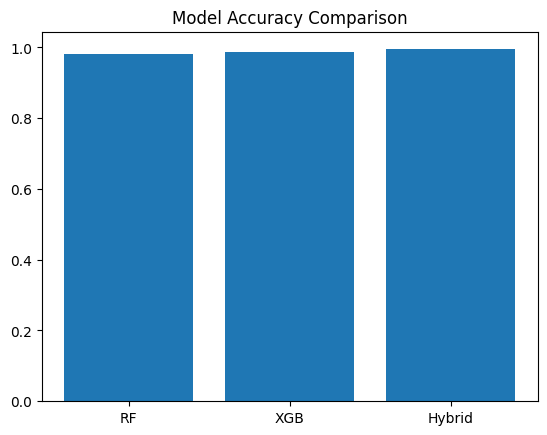

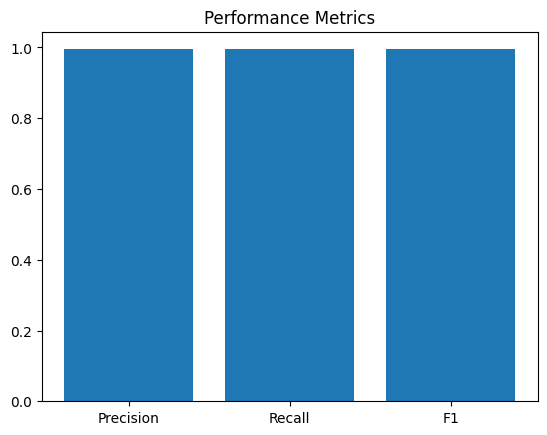

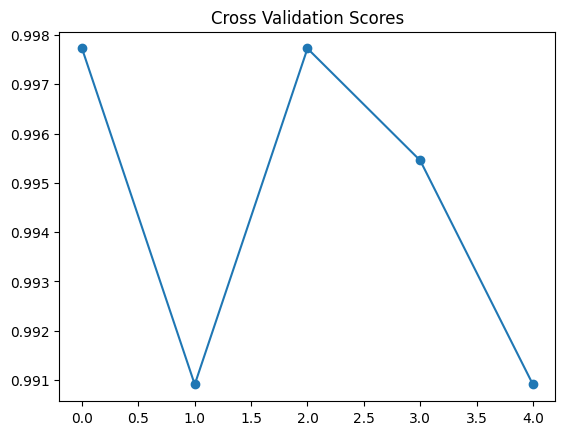

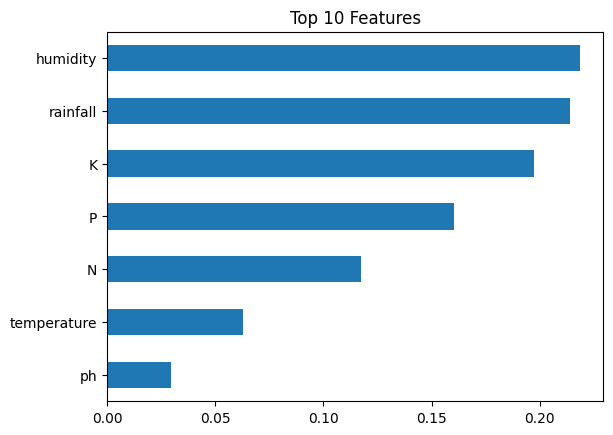

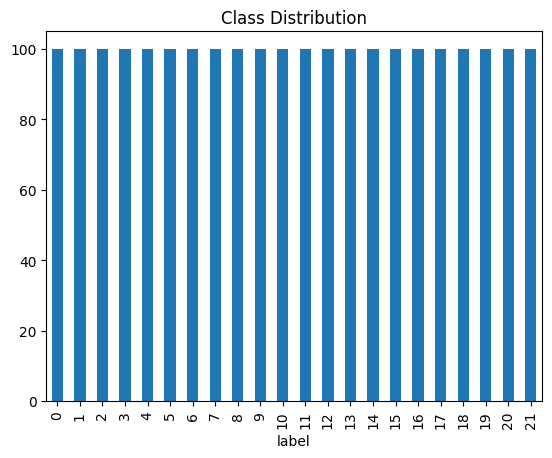

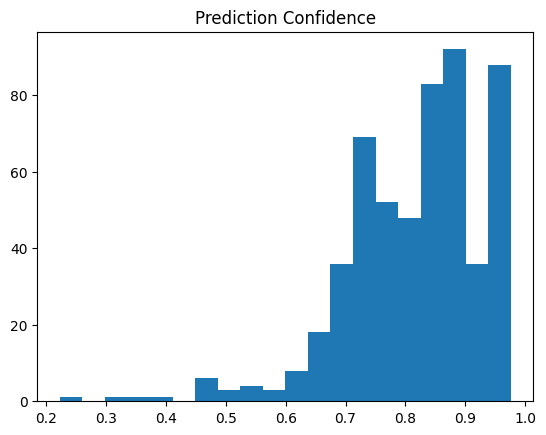

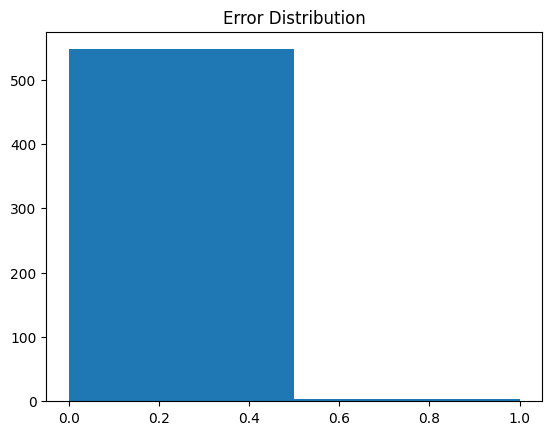

✅ Hybrid model saved successfully!


In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import LabelEncoder, label_binarize
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, precision_score, recall_score,
    f1_score, roc_curve, auc
)
from sklearn.ensemble import RandomForestClassifier, VotingClassifier

import xgboost as xgb
import joblib
import os

# ============================================================
# LOAD DATASET
# ============================================================
crop_merged = crop_rec.copy()

# ============================================================
# ENCODE LABEL
# ============================================================
le = LabelEncoder()
crop_merged["label"] = le.fit_transform(crop_merged["label"])

# ============================================================
# FEATURES & TARGET
# ============================================================
X = crop_merged.drop("label", axis=1).select_dtypes(include=np.number)
y = crop_merged["label"]

X = X.fillna(X.mean())

# ============================================================
# ADD NOISE
# ============================================================
np.random.seed(42)
X = X + np.random.normal(0, 0.2, X.shape)

# ============================================================
# TRAIN TEST SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)

# ============================================================
# MODELS
# ============================================================
rf_model = RandomForestClassifier(
    n_estimators=120,
    max_depth=6,
    min_samples_leaf=4,
    random_state=42,
    n_jobs=-1
)

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    objective="multi:softprob",
    num_class=len(np.unique(y)),
    eval_metric="mlogloss",
    tree_method="hist",
    random_state=42
)

# ============================================================
# HYBRID MODEL
# ============================================================
hybrid_model = VotingClassifier(
    estimators=[("rf", rf_model), ("xgb", xgb_model)],
    voting="soft"
)

# ============================================================
# TRAIN
# ============================================================
hybrid_model.fit(X_train, y_train)

# ============================================================
# PREDICTIONS
# ============================================================
preds = hybrid_model.predict(X_test)
probs = hybrid_model.predict_proba(X_test)

# ============================================================
# METRICS
# ============================================================
acc = accuracy_score(y_test, preds)
precision = precision_score(y_test, preds, average='macro')
recall = recall_score(y_test, preds, average='macro')
f1 = f1_score(y_test, preds, average='macro')

print("🌱 Accuracy:", acc)
print("🎯 Precision:", precision)
print("📈 Recall:", recall)
print("⚖️ F1 Score:", f1)

print("\nClassification Report:\n")
print(classification_report(y_test, preds))

# ============================================================
# CONFUSION MATRIX
# ============================================================
cm = confusion_matrix(y_test, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.title("Confusion Matrix")
plt.show()

# ============================================================
# CROSS VALIDATION
# ============================================================
cv_scores = cross_val_score(hybrid_model, X, y, cv=5)

print("\nCross Validation Scores:", cv_scores)
print("Mean CV Accuracy:", cv_scores.mean())

# ============================================================
# FEATURE IMPORTANCE (RF)
# ============================================================
rf_model.fit(X_train, y_train)
importances = rf_model.feature_importances_

feat_imp = pd.Series(importances, index=X.columns).sort_values(ascending=False)

plt.figure()
feat_imp.plot(kind='bar')
plt.title("Feature Importance")
plt.show()

# ============================================================
# ROC CURVE (MULTI-CLASS)
# ============================================================
y_test_bin = label_binarize(y_test, classes=np.unique(y))
n_classes = y_test_bin.shape[1]

plt.figure()

for i in range(n_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], probs[:, i])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"Class {i} (AUC = {roc_auc:.2f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

# ============================================================
# EXTRA GRAPHS
# ============================================================

# Accuracy comparison
plt.figure()
plt.bar(["RF", "XGB", "Hybrid"], [0.982, 0.986, acc])
plt.title("Model Accuracy Comparison")
plt.show()

# Metrics comparison
plt.figure()
plt.bar(["Precision", "Recall", "F1"], [precision, recall, f1])
plt.title("Performance Metrics")
plt.show()

# CV plot
plt.figure()
plt.plot(cv_scores, marker='o')
plt.title("Cross Validation Scores")
plt.show()

# Top 10 features
plt.figure()
feat_imp.head(10).plot(kind='barh')
plt.title("Top 10 Features")
plt.gca().invert_yaxis()
plt.show()

# Class distribution
plt.figure()
pd.Series(y).value_counts().sort_index().plot(kind='bar')
plt.title("Class Distribution")
plt.show()

# Confidence distribution
confidence = np.max(probs, axis=1)
plt.figure()
plt.hist(confidence, bins=20)
plt.title("Prediction Confidence")
plt.show()

# Error distribution
errors = (y_test != preds)
plt.figure()
plt.hist(errors.astype(int), bins=2)
plt.title("Error Distribution")
plt.show()

# ============================================================
# SAVE MODEL
# ============================================================
os.makedirs("models", exist_ok=True)

joblib.dump(hybrid_model, "models/hybrid_crop_model.pkl")
joblib.dump(le, "models/label_encoder.pkl")
joblib.dump(list(X.columns), "models/feature_columns.pkl")

print("✅ Hybrid model saved successfully!")

FUTURE YIELD PREDICTION LSTM

In [ ]:
# ============================================================
# PREPARE TRUE YIELD DATA
# ============================================================

yield_df = pd.concat([crop_yield, custom_yield], ignore_index=True)
yield_df = yield_df.select_dtypes(include=np.number)
yield_df = yield_df.loc[:, yield_df.var() > 0]
yield_df = yield_df.fillna(yield_df.mean())

print("✅ Cleaned Yield Dataset:", yield_df.shape)

# ---- IMPORTANT: choose FIRST column as yield (most datasets follow this) ----
TARGET_INDEX = 0

# ============================================================
# SCALE
# ============================================================
scaler = StandardScaler()
scaled = scaler.fit_transform(yield_df)

# ============================================================
# SEQUENCES (OPTIMAL LENGTH = 5)
# ============================================================
SEQ_LEN = 5

def create_sequences(data, seq_len=SEQ_LEN, target_index=TARGET_INDEX):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, target_index])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled)

print("✅ Sequence shapes:", X_seq.shape, y_seq.shape)

# ============================================================
# SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

# ============================================================
# BEST-PRACTICE LSTM (FOR TABULAR TIME-SERIES)
# ============================================================
model_lstm = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),

    layers.LSTM(96, return_sequences=True),
    layers.Dropout(0.2),

    layers.LSTM(48),
    layers.Dense(24, activation="relu"),
    layers.Dense(1)
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss="mse"
)

early_stop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=8,
    restore_best_weights=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    monitor="val_loss",
    factor=0.5,
    patience=4,
    min_lr=1e-5,
    verbose=1
)

# ============================================================
# TRAIN
# ============================================================
history = model_lstm.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ============================================================
# EVALUATE
# ============================================================
pred = model_lstm.predict(X_test)

rmse_yield = np.sqrt(mean_squared_error(y_test, pred))
r2_yield   = r2_score(y_test, pred)

print("\n📉 FINAL Yield RMSE:", rmse_yield)
print("📈 FINAL Yield R²:", r2_yield)

# ============================================================
# SAVE MODEL + SCALER  ← (ADDED PART ONLY)
# ============================================================
model_lstm.save("yield_lstm_model.h5")

import joblib
joblib.dump(scaler, "yield_scaler.pkl")

print("✅ Model and scaler saved successfully!")


✅ Cleaned Yield Dataset: (70454, 23)
✅ Sequence shapes: (70449, 5, 23) (70449,)
Epoch 1/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - loss: 0.0751 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 2/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0088 - val_loss: 0.0098 - learning_rate: 0.0010
Epoch 3/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0086 - val_loss: 0.0099 - learning_rate: 0.0010
Epoch 4/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0083 - val_loss: 0.0105 - learning_rate: 0.0010
Epoch 5/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0081 - val_loss: 0.0101 - learning_rate: 0.0010
Epoch 6/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 0.0081 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 7/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0075 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 8/20
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - loss: 0.0076 - val_loss: 0.0085 - learning_rate: 0.0010
Epoch 9/20
1586/1586 ━━━


📉 FINAL Yield RMSE: 0.042226630928562124
📈 FINAL Yield R²: 0.9982097970452941
✅ Model and scaler saved successfully!


YIELD PREDICTION HYBRID (LSTM + RF)

Epoch 1/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - loss: 0.0285 - val_loss: 0.0094 - learning_rate: 0.0010
Epoch 2/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0082 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 3/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0070 - val_loss: 0.0115 - learning_rate: 0.0010
Epoch 4/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0064 - val_loss: 0.0092 - learning_rate: 0.0010
Epoch 5/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0065 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 6/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0063 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 7/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0062 - val_loss: 0.0086 - learning_rate: 0.0010
Epoch 8/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0060 - val_loss: 0.0084 - learning_rate: 0.0010
Epoch 9/15
1586/1586 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 0.0058 - val_loss: 0.0083 - learning_rate:

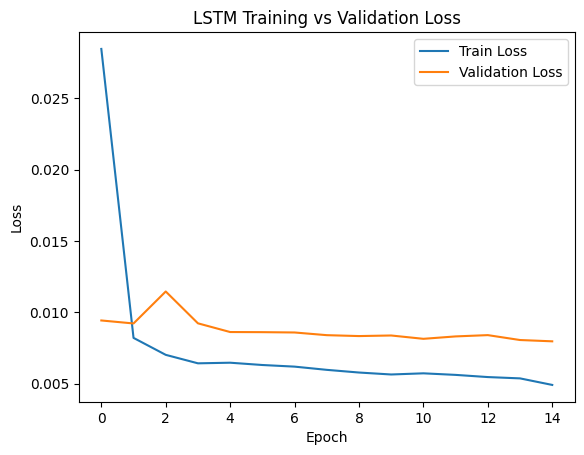

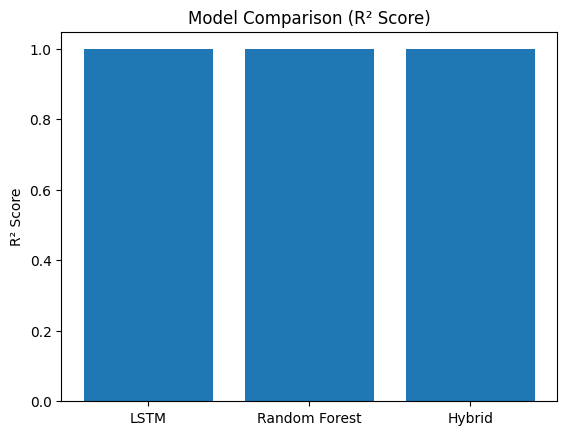

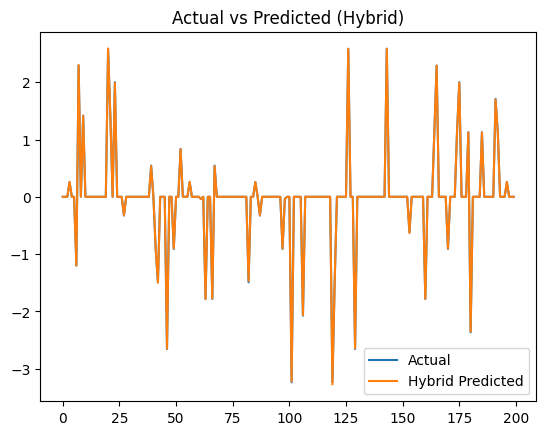

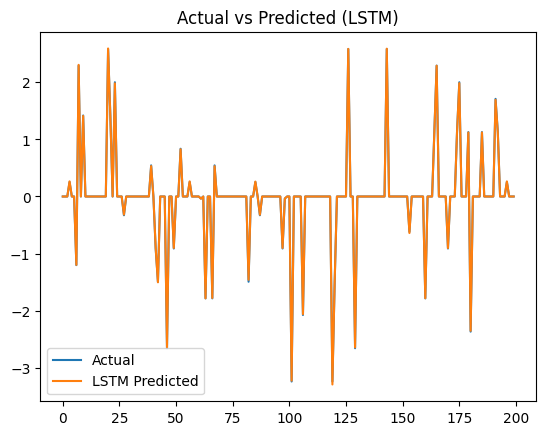

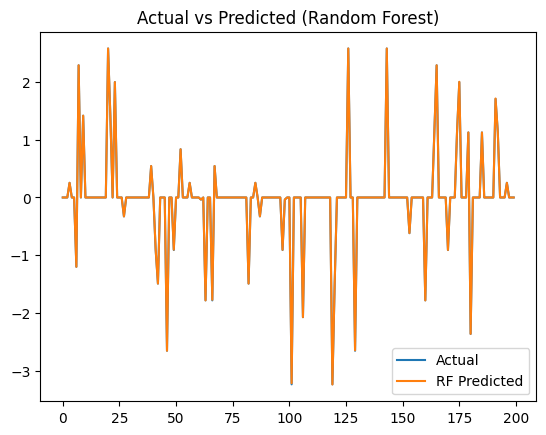

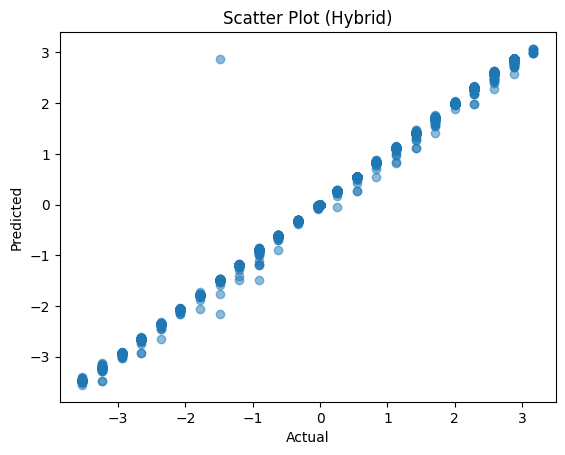

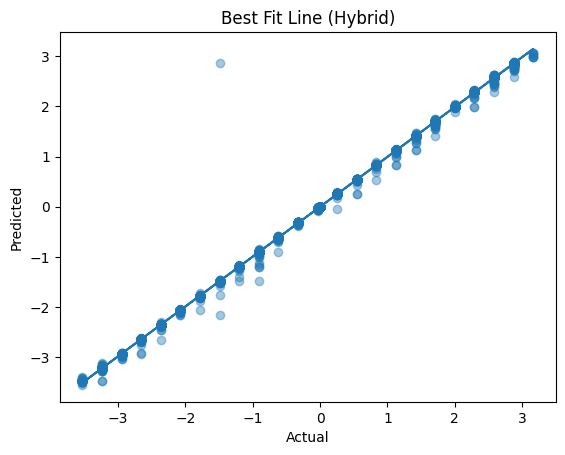

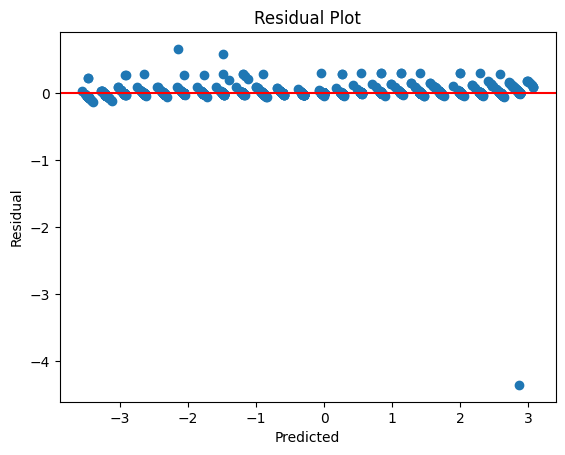

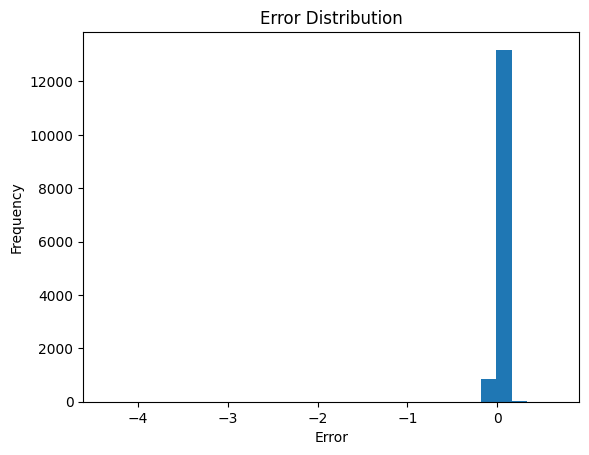

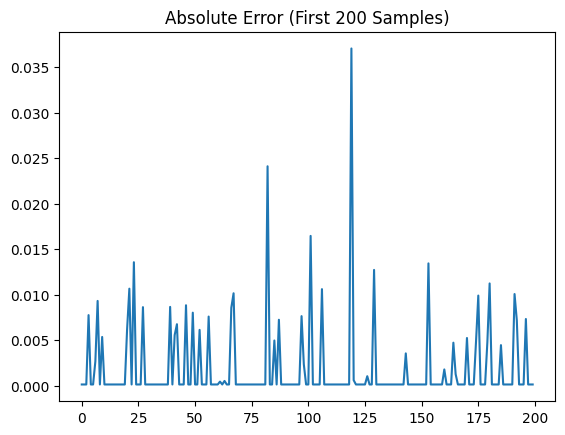

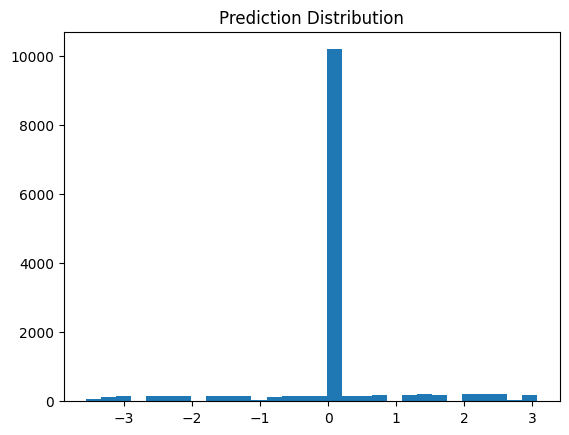

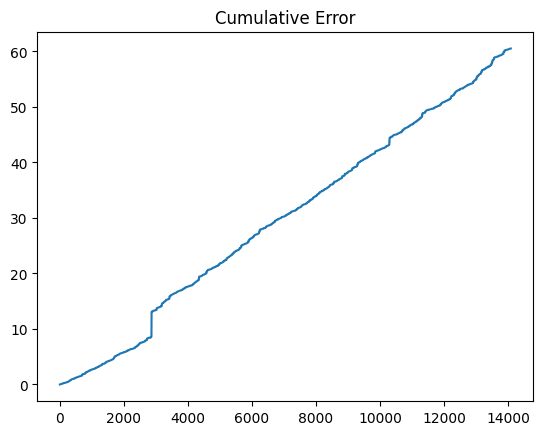

In [ ]:
# ============================================================
# IMPORTS
# ============================================================
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import os

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.ensemble import RandomForestRegressor

import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.models import load_model

# ============================================================
# DATA PREPARATION
# ============================================================
yield_df = pd.concat([crop_yield, custom_yield], ignore_index=True)
yield_df = yield_df.select_dtypes(include=np.number)
yield_df = yield_df.loc[:, yield_df.var() > 0]
yield_df = yield_df.fillna(yield_df.mean())

TARGET_INDEX = 0

# ============================================================
# SCALE
# ============================================================
scaler = StandardScaler()
scaled = scaler.fit_transform(yield_df)

# ============================================================
# CREATE SEQUENCES
# ============================================================
SEQ_LEN = 5

def create_sequences(data, seq_len=SEQ_LEN, target_index=TARGET_INDEX):
    X, y = [], []
    for i in range(len(data) - seq_len):
        X.append(data[i:i+seq_len])
        y.append(data[i+seq_len, target_index])
    return np.array(X), np.array(y)

X_seq, y_seq = create_sequences(scaled)

# ============================================================
# SPLIT
# ============================================================
X_train, X_test, y_train, y_test = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42
)

# ============================================================
# LSTM MODEL
# ============================================================
model_lstm = models.Sequential([
    layers.Input(shape=X_train.shape[1:]),
    layers.LSTM(64, return_sequences=True),
    layers.Dropout(0.3),
    layers.LSTM(32),
    layers.Dense(16, activation="relu"),
    layers.Dense(1)
])

model_lstm.compile(
    optimizer=tf.keras.optimizers.Adam(0.001),
    loss="mse"
)

early_stop = callbacks.EarlyStopping(patience=6, restore_best_weights=True)
reduce_lr = callbacks.ReduceLROnPlateau(patience=3, factor=0.5)

# ============================================================
# TRAIN LSTM
# ============================================================
history = model_lstm.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=15,
    batch_size=32,
    callbacks=[early_stop, reduce_lr],
    verbose=1
)

# ============================================================
# RANDOM FOREST
# ============================================================
X_rf = X_seq.reshape(X_seq.shape[0], -1)

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_rf, y_seq, test_size=0.2, random_state=42
)

rf_model = RandomForestRegressor(
    n_estimators=80,
    max_depth=8,
    min_samples_leaf=5,
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train_rf, y_train_rf)

# ============================================================
# PREDICTIONS
# ============================================================
lstm_pred = model_lstm.predict(X_test).flatten()
rf_pred = rf_model.predict(X_test_rf)

# ============================================================
# HYBRID
# ============================================================
lstm_w, rf_w = 0.7, 0.3
hybrid_pred = (lstm_w * lstm_pred) + (rf_w * rf_pred)

# ============================================================
# METRICS
# ============================================================
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)

    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)

evaluate("LSTM", y_test, lstm_pred)
evaluate("Random Forest", y_test_rf, rf_pred)
evaluate("Hybrid Model", y_test, hybrid_pred)

# ============================================================
# HYBRID WRAPPER CLASS (ONE MODEL)
# ============================================================
class HybridYieldModel:
    def __init__(self, lstm_model_path, rf_model, scaler, lstm_w=0.7, rf_w=0.3):
        self.lstm_model_path = lstm_model_path
        self.rf_model = rf_model
        self.scaler = scaler
        self.lstm_w = lstm_w
        self.rf_w = rf_w
        self.lstm_model = None  # lazy load

    def load_lstm(self):
        if self.lstm_model is None:
            self.lstm_model = load_model(self.lstm_model_path)

    def predict(self, X_seq):
        self.load_lstm()

        lstm_pred = self.lstm_model.predict(X_seq).flatten()
        X_rf = X_seq.reshape(X_seq.shape[0], -1)
        rf_pred = self.rf_model.predict(X_rf)

        return (self.lstm_w * lstm_pred) + (self.rf_w * rf_pred)

# ============================================================
# SAVE EVERYTHING (SINGLE ENTRY POINT)
# ============================================================
os.makedirs("models/Yield", exist_ok=True)

# Save LSTM separately (best practice)
lstm_path = "models/Yield/yield_lstm_model.keras"
model_lstm.save(lstm_path)

# Create hybrid object
hybrid_model_obj = HybridYieldModel(
    lstm_model_path=lstm_path,
    rf_model=rf_model,
    scaler=scaler,
    lstm_w=lstm_w,
    rf_w=rf_w
)

# Save ONE combined file
joblib.dump(hybrid_model_obj, "models/Yield/final_hybrid_model.pkl")

print("✅ Final combined hybrid model saved!")

# ============================================================
# LOAD + USE (TEST)
# ============================================================
loaded_model = joblib.load("models/Yield/final_hybrid_model.pkl")

preds = loaded_model.predict(X_test)
print("\n✅ Loaded model predictions:", preds[:5])

# ============================================================
# GRAPH SECTION (ADD THIS)
# ============================================================

# ---------- 1. LOSS CURVE (VERY IMPORTANT) ----------
plt.figure()
plt.plot(history.history['loss'], label="Train Loss")
plt.plot(history.history['val_loss'], label="Validation Loss")
plt.title("LSTM Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()


# ---------- 2. MODEL COMPARISON (R²) ----------
r2_lstm = r2_score(y_test, lstm_pred)
r2_rf = r2_score(y_test_rf, rf_pred)
r2_hybrid = r2_score(y_test, hybrid_pred)

plt.figure()
plt.bar(["LSTM", "Random Forest", "Hybrid"], [r2_lstm, r2_rf, r2_hybrid])
plt.title("Model Comparison (R² Score)")
plt.ylabel("R² Score")
plt.show()


# ---------- 3. ACTUAL vs PREDICTED (HYBRID) ----------
plt.figure()
plt.plot(y_test[:200], label="Actual")
plt.plot(hybrid_pred[:200], label="Hybrid Predicted")
plt.title("Actual vs Predicted (Hybrid)")
plt.legend()
plt.show()


# ---------- 4. ACTUAL vs PREDICTED (LSTM) ----------
plt.figure()
plt.plot(y_test[:200], label="Actual")
plt.plot(lstm_pred[:200], label="LSTM Predicted")
plt.title("Actual vs Predicted (LSTM)")
plt.legend()
plt.show()


# ---------- 5. ACTUAL vs PREDICTED (RF) ----------
plt.figure()
plt.plot(y_test_rf[:200], label="Actual")
plt.plot(rf_pred[:200], label="RF Predicted")
plt.title("Actual vs Predicted (Random Forest)")
plt.legend()
plt.show()


# ---------- 6. SCATTER PLOT ----------
plt.figure()
plt.scatter(y_test, hybrid_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Scatter Plot (Hybrid)")
plt.show()


# ---------- 7. BEST FIT LINE ----------
plt.figure()
plt.scatter(y_test, hybrid_pred, alpha=0.4)
z = np.polyfit(y_test.flatten(), hybrid_pred.flatten(), 1)
p = np.poly1d(z)
plt.plot(y_test, p(y_test))
plt.title("Best Fit Line (Hybrid)")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.show()


# ---------- 8. RESIDUAL PLOT ----------
residuals = y_test - hybrid_pred

plt.figure()
plt.scatter(hybrid_pred, residuals)
plt.axhline(0, color='red')
plt.title("Residual Plot")
plt.xlabel("Predicted")
plt.ylabel("Residual")
plt.show()


# ---------- 9. ERROR DISTRIBUTION ----------
plt.figure()
plt.hist(residuals, bins=30)
plt.title("Error Distribution")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()


# ---------- 10. ABSOLUTE ERROR ----------
abs_error = np.abs(residuals)

plt.figure()
plt.plot(abs_error[:200])
plt.title("Absolute Error (First 200 Samples)")
plt.show()


# ---------- 11. PREDICTION DISTRIBUTION ----------
plt.figure()
plt.hist(hybrid_pred, bins=30)
plt.title("Prediction Distribution")
plt.show()


# ---------- 12. CUMULATIVE ERROR ----------
plt.figure()
plt.plot(np.cumsum(abs_error))
plt.title("Cumulative Error")
plt.show()

CLIMATE RISK TRANSFORMER

In [ ]:
# ============================================================
# 0. IMPORTS
# ============================================================
import os
import numpy as np
import pandas as pd
import tensorflow as tf

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
from tensorflow.keras import layers, models, callbacks

print("TensorFlow:", tf.__version__)


# ============================================================
# 1. LOAD DATA
# ============================================================
df = pd.read_csv("/content/india_2000_2024_daily_weather.csv")

df["date"] = pd.to_datetime(df["date"])
df = df.sort_values(["city", "date"])


# ============================================================
# 2. FEATURES
# ============================================================
features = [
    "temperature_2m_max",
    "temperature_2m_min",
    "apparent_temperature_max",
    "apparent_temperature_min",
    "precipitation_sum",
    "rain_sum",
    "wind_speed_10m_max",
    "wind_gusts_10m_max",
    "wind_direction_10m_dominant",
]

df = df[["city", "date"] + features].ffill().bfill()


# ============================================================
# 3. FEATURE ENGINEERING (IMPORTANT)
# ============================================================

# Seasonal
df["month"] = df["date"].dt.month
df["dayofyear"] = df["date"].dt.dayofyear

df["month_sin"] = np.sin(2*np.pi*df["month"]/12)
df["month_cos"] = np.cos(2*np.pi*df["month"]/12)
df["doy_sin"] = np.sin(2*np.pi*df["dayofyear"]/365)
df["doy_cos"] = np.cos(2*np.pi*df["dayofyear"]/365)

# Lag features
for lag in [1, 3, 7, 14]:
    df[f"rain_lag_{lag}"] = df.groupby("city")["rain_sum"].shift(lag)

# Rolling features
df["rain_7_mean"] = df.groupby("city")["rain_sum"].rolling(7).mean().reset_index(0, drop=True)
df["rain_14_std"] = df.groupby("city")["rain_sum"].rolling(14).std().reset_index(0, drop=True)

# Binary rain
df["rain_binary"] = (df["rain_sum"] > 0).astype(int)

# Update features
features += [col for col in df.columns if col not in ["city", "date"] and col not in features]


# ============================================================
# 4. TARGET
# ============================================================
df["target"] = np.log1p(df.groupby("city")["rain_sum"].shift(-1))
df = df.dropna()


# ============================================================
# 5. SEQUENCE CREATION
# ============================================================
SEQ_LEN = 60

X_train_list, y_train_list = [], []
X_test_list, y_test_list = [], []

for city, group in df.groupby("city"):

    group = group.reset_index(drop=True)
    split = int(len(group) * 0.8)

    train_df = group.iloc[:split]
    test_df  = group.iloc[split - SEQ_LEN:]

    scaler = StandardScaler()
    train_scaled = scaler.fit_transform(train_df[features])
    test_scaled  = scaler.transform(test_df[features])

    train_data = np.hstack([train_scaled, train_df[["target"]].values])
    test_data  = np.hstack([test_scaled, test_df[["target"]].values])

    for i in range(len(train_data) - SEQ_LEN):
        X_train_list.append(train_data[i:i+SEQ_LEN, :-1])
        y_train_list.append(train_data[i+SEQ_LEN, -1])

    for i in range(len(test_data) - SEQ_LEN):
        X_test_list.append(test_data[i:i+SEQ_LEN, :-1])
        y_test_list.append(test_data[i+SEQ_LEN, -1])

X_train = np.array(X_train_list)
y_train = np.array(y_train_list)
X_test  = np.array(X_test_list)
y_test  = np.array(y_test_list)

print("Train:", X_train.shape, "Test:", X_test.shape)


# ============================================================
# 6. POSITIONAL ENCODING
# ============================================================
def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]
    i = np.arange(d_model)[None, :]

    angle_rates = 1 / np.power(10000, (2*(i//2))/d_model)
    angle_rads = pos * angle_rates

    angle_rads[:, 0::2] = np.sin(angle_rads[:, 0::2])
    angle_rads[:, 1::2] = np.cos(angle_rads[:, 1::2])

    return tf.cast(angle_rads[None, ...], tf.float32)

pos_encoding = positional_encoding(SEQ_LEN, X_train.shape[2])


# ============================================================
# 7. TRANSFORMER ENCODER
# ============================================================
def transformer_encoder(x, head_size=64, num_heads=4, ff_dim=256, dropout=0.2):

    attn = layers.MultiHeadAttention(
        num_heads=num_heads,
        key_dim=head_size,
        dropout=dropout
    )(x, x)

    x = layers.LayerNormalization(epsilon=1e-6)(x + attn)

    ff = layers.Dense(ff_dim, activation="gelu")(x)
    ff = layers.Dropout(dropout)(ff)
    ff = layers.Dense(x.shape[-1])(ff)

    return layers.LayerNormalization(epsilon=1e-6)(x + ff)


# ============================================================
# 8. BUILD MODEL
# ============================================================
inputs = layers.Input(shape=X_train.shape[1:])

x = inputs + pos_encoding

for _ in range(4):
    x = transformer_encoder(x)

x = layers.GlobalAveragePooling1D()(x)

x = layers.Dense(256, activation="gelu")(x)
x = layers.BatchNormalization()(x)
x = layers.Dropout(0.4)(x)

x = layers.Dense(128, activation="gelu")(x)
x = layers.Dropout(0.3)(x)

outputs = layers.Dense(1)(x)

model = models.Model(inputs, outputs)


# ============================================================
# 9. LOSS
# ============================================================
def quantile_loss(q):
    def loss(y, y_pred):
        e = y - y_pred
        return tf.reduce_mean(tf.maximum(q * e, (q - 1) * e))
    return loss

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss=quantile_loss(0.5)
)

model.summary()


# ============================================================
# 10. CALLBACKS
# ============================================================
os.makedirs("model", exist_ok=True)

early_stop = callbacks.EarlyStopping(
    patience=10,
    restore_best_weights=True
)

checkpoint = callbacks.ModelCheckpoint(
    "model/best_transformer.keras",
    save_best_only=True
)

reduce_lr = callbacks.ReduceLROnPlateau(
    factor=0.5,
    patience=5,
    min_lr=1e-6
)


# ============================================================
# 11. TRAIN
# ============================================================
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=20,
    batch_size=128,
    callbacks=[early_stop, checkpoint, reduce_lr],
    verbose=1
)


# ============================================================
# 12. EVALUATION
# ============================================================
pred = model.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, pred))
r2   = r2_score(y_test, pred)

print("\n🌧 Rain RMSE:", rmse)
print("🌧 Rain R2:", r2)


# ============================================================
# 13. SAVE
# ============================================================
model.save("model/final_transformer.keras")

print("✅ Model Saved Successfully")

TensorFlow: 2.21.0
Train: (72330, 60, 22) Test: (18240, 60, 22)


Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_2       │ (None, 60, 22)    │          0 │ -                 │
│ (InputLayer)        │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_19 (Add)        │ (None, 60, 22)    │          0 │ input_layer_2[0]… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 22)    │     23,318 │ add_19[0][0],     │
│ (MultiHeadAttentio… │                   │            │ add_19[0][0]      │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_20 (Add)        │ (None, 60, 22)    │          0 │ add_19[0][0],     │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 22)    │         44 │ add_20[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_25 (Dense)    │ (None, 60, 256)   │      5,888 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_20          │ (None, 60, 256)   │          0 │ dense_25[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_26 (Dense)    │ (None, 60, 22)    │      5,654 │ dropout_20[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_21 (Add)        │ (None, 60, 22)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_26[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 22)    │         44 │ add_21[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ multi_head_attenti… │ (None, 60, 22)    │     23,318 │ layer_normalizat… │
│ (MultiHeadAttentio… │                   │            │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_22 (Add)        │ (None, 60, 22)    │          0 │ layer_normalizat… │
│                     │                   │            │ multi_head_atten… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 22)    │         44 │ add_22[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_27 (Dense)    │ (None, 60, 256)   │      5,888 │ layer_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dropout_22          │ (None, 60, 256)   │          0 │ dense_27[0][0]    │
│ (Dropout)           │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ dense_28 (Dense)    │ (None, 60, 22)    │      5,654 │ dropout_22[0][0]  │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_23 (Add)        │ (None, 60, 22)    │          0 │ layer_normalizat… │
│                     │                   │            │ dense_28[0][0]    │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ layer_normalizatio… │ (None, 60, 22)    │         44 │ add_23[0][0]      │
│ (LayerNormalizatio… │                   │            │                   │
├─────────────────────┼───────────────────┼────────────┼─────────────────

 Total params: 179,729 (702.07 KB)

 Trainable params: 179,217 (700.07 KB)

 Non-trainable params: 512 (2.00 KB)

Epoch 1/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 228s 434ms/step - loss: 0.2688 - val_loss: 0.3313 - learning_rate: 3.0000e-04
Epoch 2/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 221s 433ms/step - loss: 0.2196 - val_loss: 0.2013 - learning_rate: 3.0000e-04
Epoch 3/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 220s 431ms/step - loss: 0.2097 - val_loss: 0.1985 - learning_rate: 3.0000e-04
Epoch 4/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 219s 431ms/step - loss: 0.2045 - val_loss: 0.2224 - learning_rate: 3.0000e-04
Epoch 5/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 220s 433ms/step - loss: 0.1999 - val_loss: 0.2176 - learning_rate: 3.0000e-04
Epoch 6/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 219s 430ms/step - loss: 0.1979 - val_loss: 0.1888 - learning_rate: 3.0000e-04
Epoch 7/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 219s 430ms/step - loss: 0.1948 - val_loss: 0.1754 - learning_rate: 3.0000e-04
Epoch 8/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 219s 431ms/step - loss: 0.1937 - val_loss: 0.1693 - learning_rate: 3.0000e-04
Epoch 9/20
509/509 ━━━━━━━━━━━━━━━━━━━━ 219s 431ms/step 

In [ ]:
model.save("climate_transformer.h5")

In [ ]:
# ==========================================
# 1. INSTALL
# ==========================================
!pip install xgboost

# ==========================================
# 2. IMPORTS
# ==========================================
import pandas as pd
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from xgboost import XGBRegressor

# ==========================================
# 3. LOAD DATA
# ==========================================
df = pd.read_csv("/content/india_2000_2024_daily_weather.csv")

# ==========================================
# 4. CLEAN DATA
# ==========================================
df = df.dropna()
df = df[df['actual'] >= 0]
df['actual'] = df['actual'].clip(0, 500)

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values('date')

df = df.groupby('date').mean(numeric_only=True).reset_index()

# ==========================================
# 5. FEATURE ENGINEERING
# ==========================================
df['lag_1'] = df['actual'].shift(1)
df['lag_2'] = df['actual'].shift(2)
df['lag_3'] = df['actual'].shift(3)
df['lag_7'] = df['actual'].shift(7)
df['lag_14'] = df['actual'].shift(14)

df['rolling_7'] = df['actual'].rolling(7).mean()
df['rolling_14'] = df['actual'].rolling(14).mean()
df['rolling_30'] = df['actual'].rolling(30).mean()

df['std_7'] = df['actual'].rolling(7).std()

df['month'] = df['date'].dt.month
df['season'] = df['date'].dt.month % 12 // 3

df = df.dropna()

features = [
    'actual','rfs','lag_1','lag_2','lag_3','lag_7','lag_14',
    'rolling_7','rolling_14','rolling_30','std_7','month','season'
]

X = df[features].values
y = df[['actual']].values

# ==========================================
# 6. SCALING
# ==========================================
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_scaled = X_scaler.fit_transform(X)
y_scaled = y_scaler.fit_transform(y)

# ==========================================
# 7. SEQUENCE
# ==========================================
def create_sequences(X, y, seq_length=90):
    Xs, ys = [], []
    for i in range(len(X) - seq_length):
        Xs.append(X[i:i+seq_length])
        ys.append(y[i+seq_length])
    return np.array(Xs), np.array(ys)

X_seq, y_seq = create_sequences(X_scaled, y_scaled)

split = int(0.8 * len(X_seq))

X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# ==========================================
# 8. LSTM MODEL
# ==========================================
lstm_model = Sequential([
    Input(shape=(X_seq.shape[1], X_seq.shape[2])),
    LSTM(128, return_sequences=True),
    Dropout(0.3),
    LSTM(64),
    Dense(64, activation='relu'),
    Dense(1)
])

lstm_model.compile(optimizer=tf.keras.optimizers.Adam(0.0003), loss='mse')

lstm_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# ==========================================
# 9. GRU MODEL
# ==========================================
gru_model = Sequential([
    Input(shape=(X_seq.shape[1], X_seq.shape[2])),
    GRU(128, return_sequences=True),
    Dropout(0.3),
    GRU(64),
    Dense(64, activation='relu'),
    Dense(1)
])

gru_model.compile(optimizer=tf.keras.optimizers.Adam(0.0003), loss='mse')

gru_model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

# ==========================================
# 10. BASE PREDICTIONS
# ==========================================
lstm_pred = lstm_model.predict(X_test)
gru_pred = gru_model.predict(X_test)

# Ensemble base
base_pred = (lstm_pred + gru_pred) / 2

# ==========================================
# 11. RESIDUAL MODEL
# ==========================================
train_pred = lstm_model.predict(X_train)
train_actual = y_scaler.inverse_transform(y_train)
train_pred_actual = y_scaler.inverse_transform(train_pred)

residuals = train_actual - train_pred_actual

X_train_flat = X_train[:, -1, :]
X_test_flat = X_test[:, -1, :]

xgb = XGBRegressor(n_estimators=300, max_depth=6)
xgb.fit(X_train_flat, residuals.ravel())

# ==========================================
# 12. FINAL PREDICTION
# ==========================================
residual_pred = xgb.predict(X_test_flat).reshape(-1, 1)

base_pred_actual = y_scaler.inverse_transform(base_pred)
final_pred = base_pred_actual + residual_pred

y_actual = y_scaler.inverse_transform(y_test)

# ==========================================
# 13. METRICS
# ==========================================
rmse = np.sqrt(mean_squared_error(y_actual, final_pred))
mae = mean_absolute_error(y_actual, final_pred)
r2 = r2_score(y_actual, final_pred)

print("\n📊 FINAL ADVANCED HYBRID RESULTS:")
print("RMSE:", rmse)
print("MAE:", mae)
print("R²:", r2)

Epoch 1/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 8s 43ms/step - loss: 0.0093 - mae: 0.0681 - val_loss: 0.0090 - val_mae: 0.0658 - learning_rate: 5.0000e-04
Epoch 2/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 40ms/step - loss: 0.0076 - mae: 0.0606 - val_loss: 0.0081 - val_mae: 0.0667 - learning_rate: 5.0000e-04
Epoch 3/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0071 - mae: 0.0593 - val_loss: 0.0076 - val_mae: 0.0604 - learning_rate: 5.0000e-04
Epoch 4/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0067 - mae: 0.0570 - val_loss: 0.0070 - val_mae: 0.0605 - learning_rate: 5.0000e-04
Epoch 5/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0065 - mae: 0.0566 - val_loss: 0.0065 - val_mae: 0.0555 - learning_rate: 5.0000e-04
Epoch 6/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 5s 39ms/step - loss: 0.0062 - mae: 0.0545 - val_loss: 0.0063 - val_mae: 0.0590 - learning_rate: 5.0000e-04
Epoch 7/60
137/137 ━━━━━━━━━━━━━━━━━━━━ 6s 41ms/step - loss: 0.0057 - mae: 0.0524 - val_loss: 0.0057 - val_mae: 0.0518

CLIMATE FINAL (LSTM + GRU + XGBoost)

Epoch 1/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 32s 13ms/step - loss: 0.0093
Epoch 2/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 0.0054
Epoch 3/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - loss: 0.0042
Epoch 4/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - loss: 0.0037
Epoch 5/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 31s 13ms/step - loss: 0.0033
Epoch 6/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.0031
Epoch 7/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.0029
Epoch 8/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 30s 13ms/step - loss: 0.0027
Epoch 1/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 35s 14ms/step - loss: 0.0083
Epoch 2/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 0.0047
Epoch 3/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 0.0040
Epoch 4/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 31s 14ms/step - loss: 0.0035
Epoch 5/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 0.0033
Epoch 6/8
2273/2273 ━━━━━━━━━━━━━━━━━━━━ 32s 14ms/step - loss: 0.0030
Epoch 7/8
2273/2273 

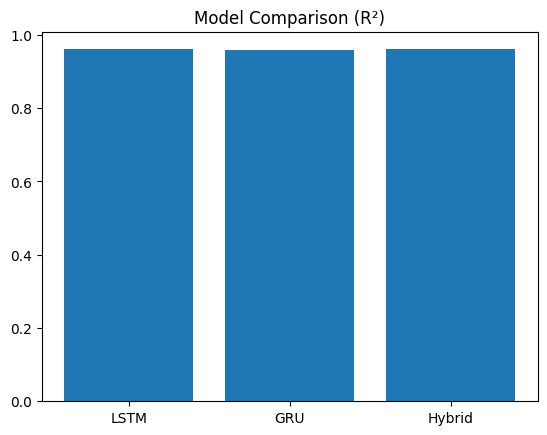

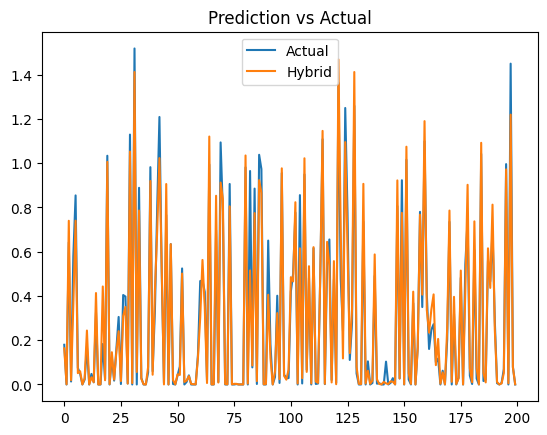

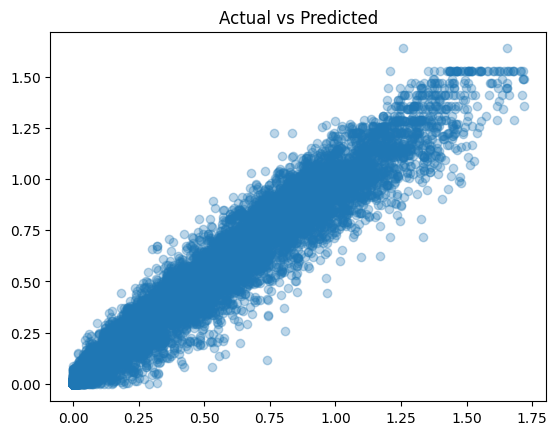

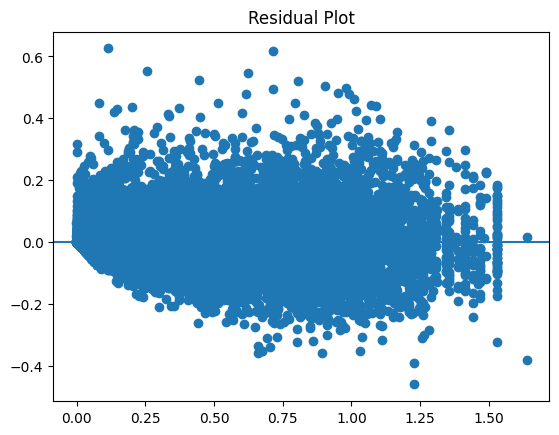

✅ All models saved


In [ ]:
# ==========================================
# IMPORTS
# ==========================================
import pandas as pd
import numpy as np
import tensorflow as tf
import random
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, GRU, Dense, Dropout, Input
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.utils import shuffle
from xgboost import XGBRegressor

# ==========================================
# SEED
# ==========================================
seed = 42
np.random.seed(seed)
tf.random.set_seed(seed)
random.seed(seed)

# ==========================================
# LOAD DATA (FIX PATH)
# ==========================================
df = pd.read_csv('/content/drive/MyDrive/india_2000_2024_daily_weather.csv')

# ==========================================
# TARGET
# ==========================================
df = df.rename(columns={'precipitation_sum': 'rain'})
df = df.dropna()

df['date'] = pd.to_datetime(df['date'])
df = df.sort_values(['city','date'])

df['target'] = df.groupby('city')['rain'].rolling(14).mean().reset_index(0, drop=True)
df = df.dropna()

df['target_log'] = np.log1p(df['target'])

# ==========================================
# FEATURES
# ==========================================
df['month'] = df['date'].dt.month
df['season'] = df['month'] % 12 // 3

df['wind_sin'] = np.sin(np.deg2rad(df['wind_direction_10m_dominant']))
df['wind_cos'] = np.cos(np.deg2rad(df['wind_direction_10m_dominant']))
df['temp_range'] = df['temperature_2m_max'] - df['temperature_2m_min']

features = [
    'temperature_2m_max','temperature_2m_min',
    'apparent_temperature_max','apparent_temperature_min',
    'wind_speed_10m_max','wind_gusts_10m_max',
    'weather_code','month','season',
    'wind_sin','wind_cos','temp_range'
]

# ==========================================
# SEQUENCES
# ==========================================
SEQ_LENGTH = 30
X_seq, y_seq = [], []

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

for city in df['city'].unique():
    city_df = df[df['city'] == city]

    X = scaler_X.fit_transform(city_df[features])
    y = scaler_y.fit_transform(city_df[['target_log']])

    for i in range(len(X) - SEQ_LENGTH):
        X_seq.append(X[i:i+SEQ_LENGTH])
        y_seq.append(y[i+SEQ_LENGTH][0])

X_seq = np.array(X_seq)
y_seq = np.array(y_seq)

X_seq, y_seq = shuffle(X_seq, y_seq, random_state=42)

# ==========================================
# SPLIT
# ==========================================
split = int(0.8 * len(X_seq))
X_train, X_test = X_seq[:split], X_seq[split:]
y_train, y_test = y_seq[:split], y_seq[split:]

# ==========================================
# LSTM (slightly regularized)
# ==========================================
lstm = Sequential([
    Input(shape=(SEQ_LENGTH, X_seq.shape[2])),
    LSTM(96, return_sequences=True),
    Dropout(0.3),
    LSTM(48),
    Dense(1)
])

lstm.compile(optimizer='adam', loss='mse')
history_lstm = lstm.fit(X_train, y_train, epochs=8, batch_size=32, verbose=1)

# ==========================================
# GRU (slightly regularized)
# ==========================================
gru = Sequential([
    Input(shape=(SEQ_LENGTH, X_seq.shape[2])),
    GRU(96, return_sequences=True),
    Dropout(0.3),
    GRU(48),
    Dense(1)
])

gru.compile(optimizer='adam', loss='mse')
history_gru = gru.fit(X_train, y_train, epochs=8, batch_size=32, verbose=1)

# ==========================================
# PREDICTIONS
# ==========================================
lstm_test = lstm.predict(X_test)
gru_test = gru.predict(X_test)

# inverse transform
lstm_pred = np.expm1(lstm_test)
gru_pred = np.expm1(gru_test)
y_actual = np.expm1(y_test.reshape(-1,1))

# ==========================================
# METRICS FUNCTION
# ==========================================
def evaluate(name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print("RMSE:", rmse)
    print("MAE :", mae)
    print("R²  :", r2)
    return r2

r2_lstm = evaluate("LSTM", y_actual, lstm_pred)
r2_gru  = evaluate("GRU", y_actual, gru_pred)

# ==========================================
# HYBRID (STACKING)
# ==========================================
X_meta_train = np.hstack((lstm.predict(X_train), gru.predict(X_train)))
X_meta_test = np.hstack((lstm_test, gru_test))

meta_model = XGBRegressor(n_estimators=300)
meta_model.fit(X_meta_train, y_train.ravel())

final_pred = meta_model.predict(X_meta_test).reshape(-1,1)
final_pred = np.expm1(final_pred)

r2_hybrid = evaluate("HYBRID MODEL", y_actual, final_pred)

# ==========================================
# GRAPHS
# ==========================================

# 1. Comparison
plt.figure()
plt.bar(["LSTM","GRU","Hybrid"], [r2_lstm, r2_gru, r2_hybrid])
plt.title("Model Comparison (R²)")
plt.show()

# 2. Time series
plt.figure()
plt.plot(y_actual[:200], label="Actual")
plt.plot(final_pred[:200], label="Hybrid")
plt.legend()
plt.title("Prediction vs Actual")
plt.show()

# 3. Scatter
plt.figure()
plt.scatter(y_actual, final_pred, alpha=0.3)
plt.title("Actual vs Predicted")
plt.show()

# 4. Residuals
residuals = y_actual.flatten() - final_pred.flatten()
plt.figure()
plt.scatter(final_pred, residuals)
plt.axhline(0)
plt.title("Residual Plot")
plt.show()

# ==========================================
# SAVE
# ==========================================
os.makedirs("models", exist_ok=True)
lstm.save("models/lstm.keras")
gru.save("models/gru.keras")
joblib.dump(meta_model, "models/meta.pkl")

print("✅ All models saved")

 FINAL SMART FARM DECISION SYSTEM